In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles

def kernel(x1, x2):
    """
    高斯核函数
    :param x1: 输入x1
    :param x2: 输入x2
    :return:  返回相乘的值
    """
    sigma = 0.1  # 高斯核函数参数
    L2 = np.sum(x1**2, 1).reshape(-1, 1) + np.sum(x2**2, 1) - 2 * x1 @ x2.T
    result = np.exp(-L2 / (2 * sigma**2))
    return result


import numpy as np
import matplotlib.pyplot as plt

class K_mean():
    """
    k_mean 聚类
    """
    def __init__(self):
        pass
    def train(self, Y, k):
        mean = np.mean(Y, axis=0)  # 求均值
        std = np.std(Y, axis=0)  # 求标准差
        Y = (Y-mean)/std  # 标准化
        row = Y.shape[0]  # 一共有多少数据
        centers = Y[np.random.choice(row, size=k), :]  # 随机抽取k个点作为中心点
        result = np.zeros(shape=(row, k))  # 初始化用于储存结果
        while True:
            old_center = centers.copy()  # 复制一份中心点
            for i in np.arange(k):  # 迭代每一个中心点
                distance = Y-centers[i, :]  # 每一个样本都减去中心点
                L2 = np.linalg.norm(distance, ord=2, axis=1)  # 求L2范数
                result[:, i] = L2  # 保存结果
            min_position = np.argmin(result, axis=1)  # 比较，查看该样本点属于哪一类

            # 迭代更新每一个中心点
            for j in np.arange(k):
                # 取出索引
                index = np.argwhere(min_position == j).reshape(-1)
                # 按行取出对应的样本值并求出均值
                mean = Y[index, :].mean(axis=0)
                # 更新样本点
                centers[j, :] = mean
            # 如果中心点不再更新，则模型结束
            if (old_center == centers).all():
                break
        # 绘图
        plot_figure(x, min_position)


class Spectral_cluster():
    """谱聚类"""
    def __init__(self):
        pass
    def train(self, x, k):
        W = kernel(x, x)  # 邻接矩阵W
        D = np.diag(np.sum(W, axis=1))  # 度矩阵D
        L = D-W  # 拉普拉斯矩阵

        eigenvalues, eigenvectors = np.linalg.eig(L)  # 计算特征值和特征向量

        min_k = np.argsort(eigenvalues)[:k]  # 取出前小k个特征值对应索引
        Y = eigenvectors[:, min_k]  # 取出前k列特征向量作为Y

        k_mean = K_mean()  # 初始化k_mean聚类方法
        k_mean.train(Y, 2)  # 实现聚类，聚成两类


def plot_figure(x, label):
    # 绘图函数
    color_map={0:"r",1:"g",2:"b"}
    color=[color_map[i] for i in label]
    plt.scatter(x[:,0],x[:,1],c=color)
    plt.show()

if __name__ == '__main__':
    k=2  # 保留前k个特征值
    x, y = make_circles(n_samples=1000, factor=0.5, noise=0.05)  # 生成数据集
    spectral_cluster=Spectral_cluster()  # 初始化模型
    spectral_cluster.train(x,k)  # 导入模型训练集

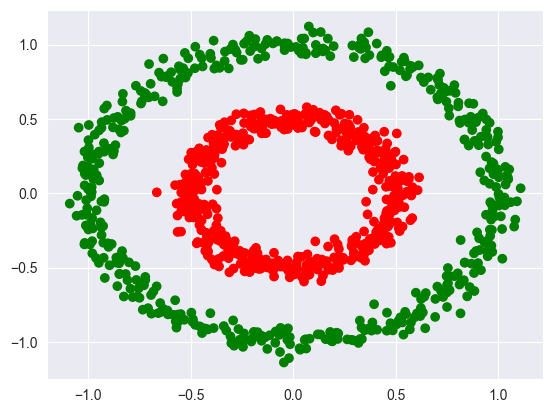

In [1]:
import numpy as np  # 用于数值计算（矩阵运算、数组操作等）
import matplotlib.pyplot as plt  # 用于数据可视化（绘制散点图）
from sklearn.datasets import make_circles  # 从sklearn生成环形数据集（用于测试聚类效果）

def kernel(x1, x2):
    """
    高斯核函数（RBF核）：将低维数据映射到高维空间，解决非线性可分问题
    :param x1: 输入样本集1（形状为[n_samples1, n_features]）
    :param x2: 输入样本集2（形状为[n_samples2, n_features]）
    :return: 核矩阵（形状为[n_samples1, n_samples2]，每个元素表示x1和x2样本的相似度）
    """
    sigma = 0.1  # 高斯核参数（控制核函数的宽窄，影响相似度计算）
    # 计算x1和x2的L2范数平方（优化版，避免循环计算）
    # np.sum(x1**2, 1).reshape(-1, 1)：x1每个样本的平方和（形状[n1,1]）
    # np.sum(x2**2, 1)：x2每个样本的平方和（形状[1,n2]）
    # 2 * x1 @ x2.T：x1与x2的内积乘以2（矩阵乘法）
    L2 = np.sum(x1**2, 1).reshape(-1, 1) + np.sum(x2**2, 1) - 2 * x1 @ x2.T
    # 高斯核公式：exp(-L2/(2*sigma²))，值越大表示样本越相似
    result = np.exp(-L2 / (2 * sigma**2))
    return result


class K_mean():
    """K-means聚类算法：基于距离的硬聚类方法"""
    def __init__(self):
        # 初始化方法（无参数，仅占位）
        pass

    def train(self, Y, k):
        """
        训练K-means模型
        :param Y: 输入数据（谱聚类中为特征向量矩阵）
        :param k: 聚类簇数
        """
        # 数据标准化（消除量纲影响，使聚类更稳定）
        mean = np.mean(Y, axis=0)  # 计算每列（特征）的均值
        std = np.std(Y, axis=0)    # 计算每列（特征）的标准差
        Y = (Y - mean) / std       # 标准化：(数据-均值)/标准差

        row = Y.shape[0]  # 获取样本数量（Y的行数）
        # 随机初始化k个聚类中心（从样本中随机选k个点）
        centers = Y[np.random.choice(row, size=k), :]  # 形状为[k, n_features]

        # 初始化存储每个样本到k个中心的距离（形状为[row, k]）
        result = np.zeros(shape=(row, k))

        # 迭代更新聚类中心，直到收敛
        while True:
            old_center = centers.copy()  # 保存当前中心（用于判断是否收敛）

            # 计算每个样本到每个中心的距离
            for i in np.arange(k):  # 遍历每个聚类中心
                distance = Y - centers[i, :]  # 每个样本与第i个中心的差（形状[row, n_features]）
                L2 = np.linalg.norm(distance, ord=2, axis=1)  # 计算L2范数（欧氏距离），结果为[row,]
                result[:, i] = L2  # 第i列存储样本到第i个中心的距离

            # 确定每个样本的聚类标签（距离最近的中心）
            min_position = np.argmin(result, axis=1)  # 对每行取最小值索引，形状为[row,]

            # 更新每个聚类中心（取该簇所有样本的均值）
            for j in np.arange(k):  # 遍历每个簇
                # 找到属于第j簇的样本索引
                index = np.argwhere(min_position == j).reshape(-1)  # 形状为[该簇样本数,]
                # 计算该簇样本的均值（作为新中心）
                mean = Y[index, :].mean(axis=0)  # 按列求均值，形状为[n_features,]
                centers[j, :] = mean  # 更新第j个中心

            # 判断是否收敛：若新旧中心完全相同，则停止迭代
            if (old_center == centers).all():
                break

        # 聚类完成后，调用绘图函数可视化结果
        plot_figure(x, min_position)  # x是原始数据，min_position是聚类标签


class Spectral_cluster():
    """谱聚类算法：基于图论的聚类方法，适用于非线性可分数据"""
    def __init__(self):
        # 初始化方法（无参数，仅占位）
        pass

    def train(self, x, k):
        """
        训练谱聚类模型
        :param x: 原始输入数据（形状为[n_samples, n_features]）
        :param k: 保留的特征向量数量（通常等于聚类簇数）
        """
        # 步骤1：构建邻接矩阵W（表示样本间的相似度）
        # 调用高斯核函数计算，W[i,j]表示样本i和j的相似度
        W = kernel(x, x)  # 形状为[n_samples, n_samples]

        # 步骤2：构建度矩阵D（对角矩阵，对角线元素为W每行的和）
        # np.sum(W, axis=1)：计算每行的和（每个样本的"度"），形状为[n_samples,]
        # np.diag()：将一维数组转为对角矩阵，形状为[n_samples, n_samples]
        D = np.diag(np.sum(W, axis=1))

        # 步骤3：构建拉普拉斯矩阵L（L = D - W）
        L = D - W  # 形状为[n_samples, n_samples]，用于刻画图的结构

        # 步骤4：计算L的特征值和特征向量
        eigenvalues, eigenvectors = np.linalg.eig(L)  # 特征值.shape=[n_samples,], 特征向量.shape=[n_samples, n_samples]

        # 步骤5：取最小的k个特征值对应的特征向量（谱聚类核心）
        min_k = np.argsort(eigenvalues)[:k]  # 对特征值排序，取前k个最小的索引
        Y = eigenvectors[:, min_k]  # 提取对应特征向量，形状为[n_samples, k]

        # 步骤6：用K-means对特征向量Y进行聚类（得到最终标签）
        k_mean = K_mean()  # 初始化K-means模型
        k_mean.train(Y, 2)  # 对Y聚类，聚成2类（环形数据适合2类）


def plot_figure(x, label):
    """
    绘制聚类结果散点图
    :param x: 原始数据（形状为[n_samples, 2]，便于二维可视化）
    :param label: 聚类标签（形状为[n_samples,]，每个元素表示样本的簇类别）
    """
    color_map = {0: "r", 1: "g", 2: "b"}  # 定义标签与颜色的映射（支持0/1/2三类）
    # 根据标签生成颜色列表（每个样本对应一个颜色）
    color = [color_map[i] for i in label]
    # 绘制散点图：x轴为第0列特征，y轴为第1列特征，颜色为聚类结果
    plt.scatter(x[:, 0], x[:, 1], c=color)
    plt.show()  # 显示图像


if __name__ == '__main__':
    k = 2  # 谱聚类中保留的特征向量数量（等于聚类簇数）
    # 生成环形数据集（非线性可分，适合谱聚类测试）
    # n_samples=1000：1000个样本；factor=0.5：内外环半径比例；noise=0.05：添加噪声
    x, y = make_circles(n_samples=1000, factor=0.5, noise=0.05)

    spectral_cluster = Spectral_cluster()  # 初始化谱聚类模型
    spectral_cluster.train(x, k)  # 训练模型（输入数据x和特征向量数量k）